<a href="https://colab.research.google.com/github/codeKrantz/PyTorch-for-deep-learning/blob/main/01_pytorch_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#PyTorch Workflow

In [149]:
what_were_covering = {1: "data",
                      2: "build a model",
                      3: "fitting a model (training)",
                      4: "making predictions/inferences",
                      5: "saving and loading models",
                      6: "Putting it all together"}

In [150]:
import torch
from torch import nn #nn contains building blocks for building networks
import matplotlib.pyplot as plt

#check version
torch.__version__

'2.11.0+cu128'

## 1. Data: preparing and loading
* Excel Sheets
* Images
* Videos
* Audio
* DNA
* Text

In [151]:
#Lets us linear regression

#Creating know parameters
weight = 0.7
bias = 0.3

start = 0
end = 1
step  = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
# y = mx + c
y = weight * X + bias

X[:10], y[:10],


(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [152]:
#they are the same length
len(X), len(y)

(50, 50)

### Splitting Data into Trainning and Test Sets

In [153]:
#using an 80/20 split

trian_split = int(0.8 * len(X))
X_train, y_train = X[:trian_split], y[:trian_split]
X_test, y_test = X[trian_split:], y[trian_split:]

#number of sets/samples
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [154]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

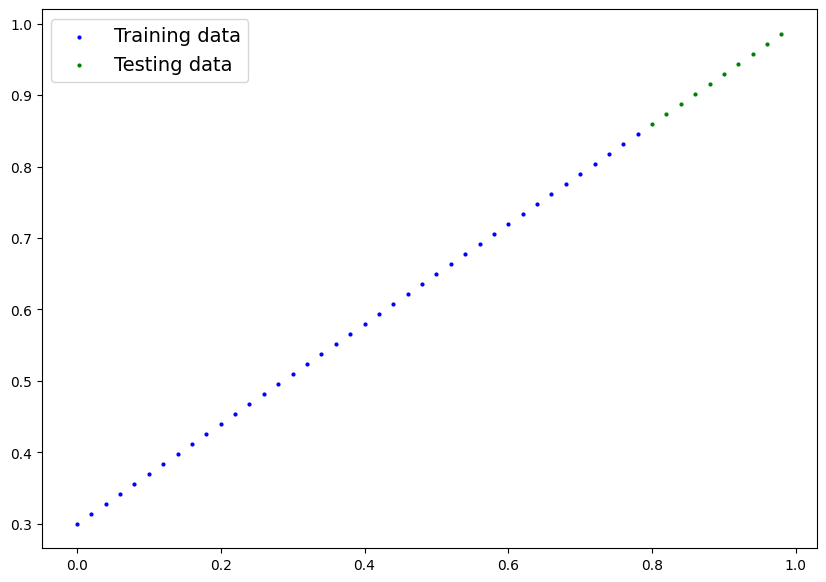

In [155]:
plot_predictions()

## Build Model

In [156]:
# Create a Linear Regression model class
class LinearRegressionModel(nn.Module): # <- almost everything in PyTorch is a nn.Module (think of this as neural network lego blocks)
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, # <- start with random weights (this will get adjusted as the model learns)
                                                dtype=torch.float), # <- PyTorch loves float32 by default
                                   requires_grad=True) # <- can we update this value with gradient descent?)

        self.bias = nn.Parameter(torch.randn(1, # <- start with random bias (this will get adjusted as the model learns)
                                            dtype=torch.float), # <- PyTorch loves float32 by default
                                requires_grad=True) # <- can we update this value with gradient descent?))

    # Forward defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" is the input data (e.g. training/testing features)
        return self.weights * x + self.bias # <- this is the linear regression formula (y = m*x + b)

### Model Building essentials
* torch.nn - for neural networks
* torch.nn.Parameters - what the model is trying to learn
* torch.nn.Module - base class

### Checking contents of the Model

In [157]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionModel()

# Check the nn.Parameter(s) within the nn.Module subclass we created
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [158]:
#List name parameters
model_0.state_dict()

#Goal: addjust produced parameters to 0.7 and 0.3 respectively

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

## Making predictions using torch.infereance_mode()

In [159]:
X_test, y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [160]:
#making predictions
with torch.inference_mode(): #inference_mode turns off gradient tracking
  y_preds = model_0(X_test)

y_preds


tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

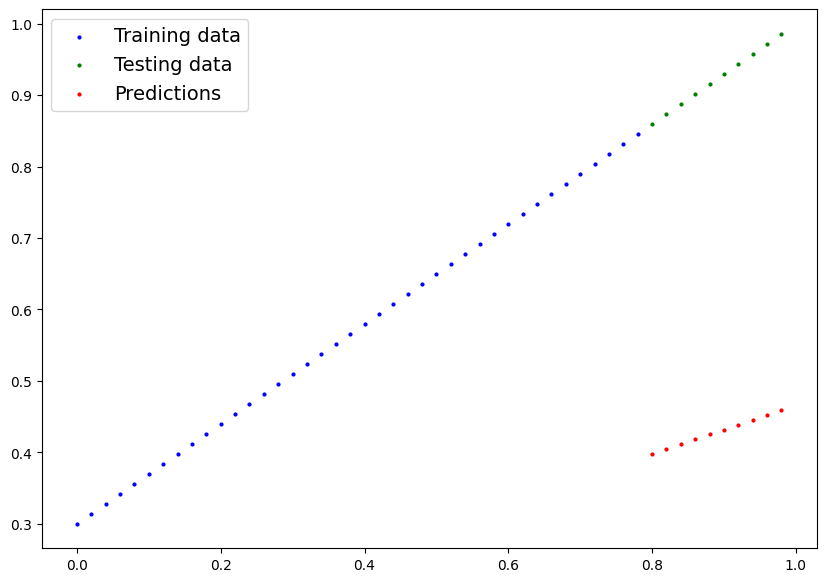

In [161]:
#making random predictions on random parameters -> will improve
plot_predictions(predictions=y_preds)

### Train Model
* Moving from unknown parameters to known parameters
* Improved representation of the data
* Measured incorrectness using a loss function
* Weights and bias will be tweeked to decrease the result of the loss function

In [162]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [163]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [164]:
#Setup a loss function
loss_fn = nn.L1Loss()

#Setup an Optimizer (stochastic gradient descent)
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01) #lr -> learning rate -> very importatn hyperparameter

In [165]:
loss_fn

L1Loss()

### Building a training loop and a testing loop

In [166]:
from os import lseek
#epoch in a single loop through the data
epochs = 200

#Track differnt values -> used for model comparision and improvement
epoch_count = []
loss_values = []
test_loss_values = []

#loop through data in TRAINING LOOP:
for epoch in range(epochs):
  #set the model to training mode
  model_0.train() #sets all parameters to require gradients if it is an option

  #Forward pass
  y_pred = model_0(X_train)

  #Calculating loss: Mean Absolute Error (MAE)
  loss = loss_fn(y_pred, y_train) #input -> target
  print(f"LOSS:{loss}")
  #Optimizer zero grad
  optimizer.zero_grad()

  #Perform backproagration on the loss with respect to model parameters
  loss.backward()

  #perform gradient decent
  optimizer.step()

  #TESTING:
  model_0.eval() #turns off gradient tracking
  with torch.inference_mode():# turns off gradient tracking and a few other things
    #Do forward pass
    test_pred = model_0(X_test)

    #calculate loss
    test_loss = loss_fn(test_pred, y_test)

  #print results
  if epoch % 10 == 0:
    epoch_count.append(epoch)
    loss_values.append(loss)
    test_loss_values.append(test_loss)
    print(f"Epoch: {epoch} | Test: {loss}, Test loss: {test_loss}")


  print(model_0.state_dict())

LOSS:0.31288138031959534
Epoch: 0 | Test: 0.31288138031959534, Test loss: 0.48106518387794495
OrderedDict({'weights': tensor([0.3406]), 'bias': tensor([0.1388])})
LOSS:0.3013603389263153
OrderedDict({'weights': tensor([0.3445]), 'bias': tensor([0.1488])})
LOSS:0.28983935713768005
OrderedDict({'weights': tensor([0.3484]), 'bias': tensor([0.1588])})
LOSS:0.2783183455467224
OrderedDict({'weights': tensor([0.3523]), 'bias': tensor([0.1688])})
LOSS:0.26679736375808716
OrderedDict({'weights': tensor([0.3562]), 'bias': tensor([0.1788])})
LOSS:0.2552763521671295
OrderedDict({'weights': tensor([0.3601]), 'bias': tensor([0.1888])})
LOSS:0.24375534057617188
OrderedDict({'weights': tensor([0.3640]), 'bias': tensor([0.1988])})
LOSS:0.23223432898521423
OrderedDict({'weights': tensor([0.3679]), 'bias': tensor([0.2088])})
LOSS:0.22071333229541779
OrderedDict({'weights': tensor([0.3718]), 'bias': tensor([0.2188])})
LOSS:0.20919232070446014
OrderedDict({'weights': tensor([0.3757]), 'bias': tensor([0.228

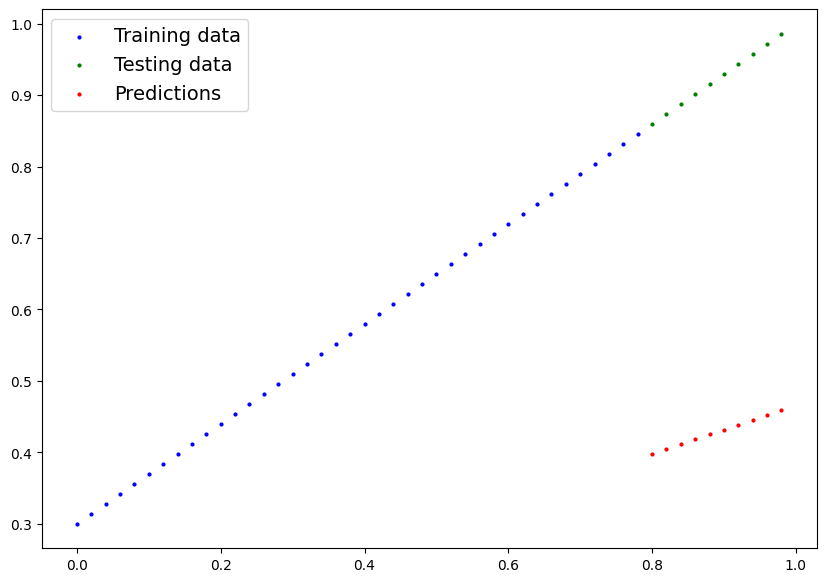

In [167]:
#Old predictions
with torch.inference_mode():
  y_preds_new = model_0(X_test)
  plot_predictions(predictions=y_preds)


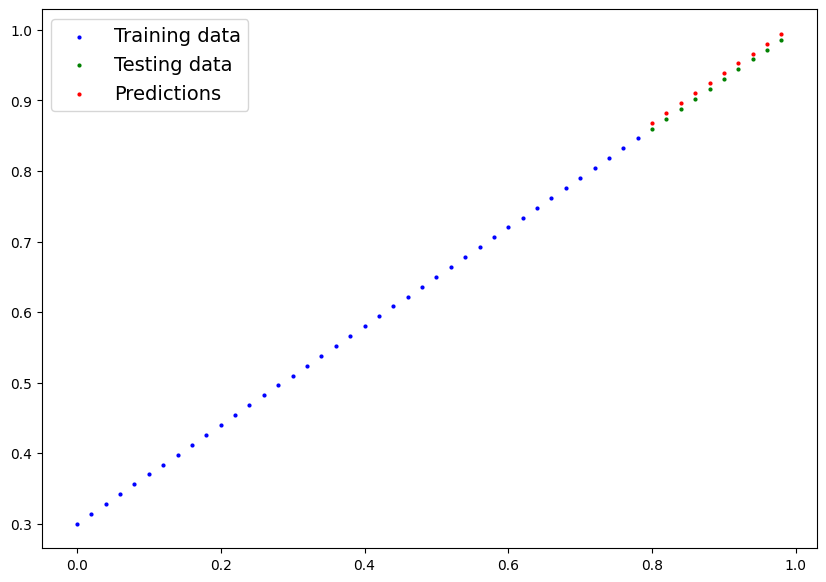

In [168]:
#new Predictions after running a few loops, much better
with torch.inference_mode():
  y_preds_new = model_0(X_test)
  plot_predictions(predictions=y_preds_new)

In [169]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

### Want to see a converging loss graph

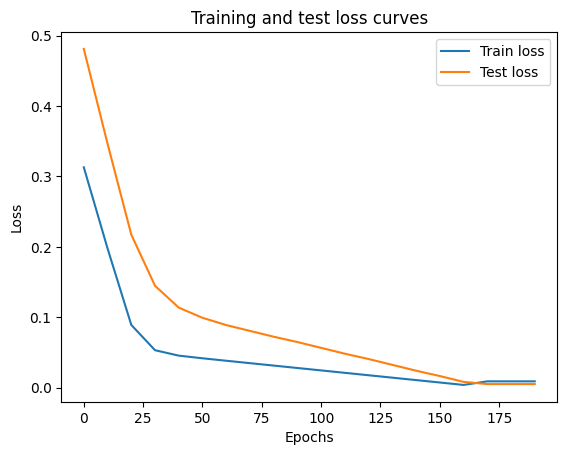

In [170]:
#Plot loss curves
import numpy as np

#need numpy values
plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

## Saving a model in Pytorch
Three main methods for saving and loading
* `torch.save()`-> pkl
* `torch.load()` -> Save Pytorch object
* `torch.nn.Module.load_state_dict()` -> allows to load a model's saved state dictionary

In [171]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [172]:
#Saving model
from pathlib import Path

#Create model directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

#Model save path
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

#Save the state dict -> recommended
print(f"Saving model to {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(), f=MODEL_SAVE_PATH)

Saving model to models/01_pytorch_workflow_model_0.pth


In [173]:
!ls -l models/

total 4
-rw-r--r-- 1 root root 2117 Jul 28 03:59 01_pytorch_workflow_model_0.pth


## Loading a model

In [174]:
#Create a new instance of the model class and load saved state dict
loaded_model_0 = LinearRegressionModel()

#load state dict
loaded_model_0.load_state_dict(torch.load(MODEL_SAVE_PATH))

<All keys matched successfully>

In [175]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [176]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [177]:
#Making predictions to make sure its the same
loaded_model_0.eval()
with torch.inference_mode():
  loaded_model_preds = loaded_model_0(X_test)

loaded_model_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [178]:
#Comparing with OG model preds
model_0.eval()
with torch.inference_mode():
  y_preds = model_0(X_test)
y_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

## All together

In [179]:
#importing pytorch and matplotlin

In [180]:
import torch
from torch import nn
import matplotlib.pyplot as plt

#Check pytorch version
torch.__version__


'2.11.0+cu128'

In [181]:
#device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


### Data

In [182]:
#Create data using linear regression formula of y = weight * x + bias
weight = 0.7
bias = 0.3


#Create range values
start = 0
end = 1
step = 0.02

#x and y {features and lables}
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X * bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.0000],
         [0.0042],
         [0.0084],
         [0.0126],
         [0.0168],
         [0.0210],
         [0.0252],
         [0.0294],
         [0.0336],
         [0.0378]]))

In [183]:
#Split data
train_split = int(0.8 * len(X))
#Creating 80/20 split
X_train, y_train = X[:trian_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train)

(40, 40)

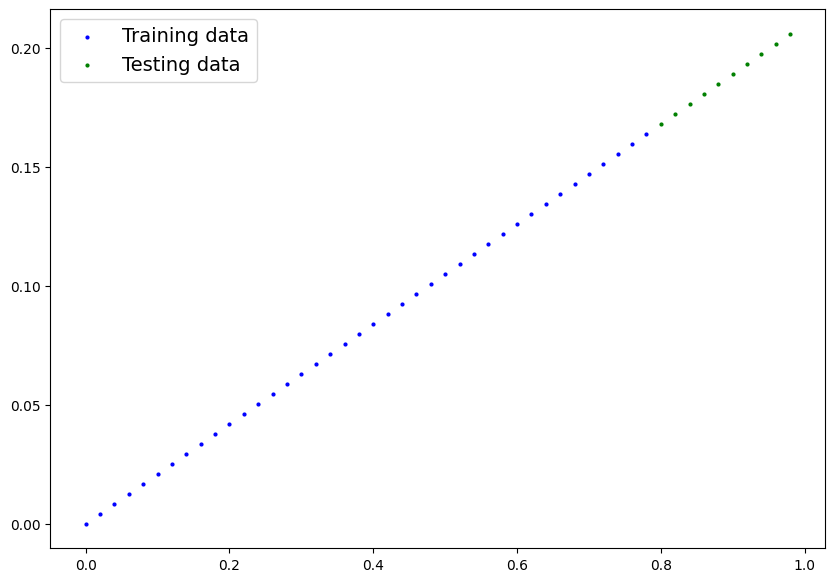

In [184]:
#Plot data

plot_predictions(X_train, y_train, X_test, y_test)

### Building a linear model

In [185]:
# Subclass nn.Module to make our model
class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        # Use nn.Linear() for creating the model parameters
        self.linear_layer = nn.Linear(in_features=1,
                                      out_features=1)

    # Define the forward computation (input data x flows through nn.Linear())
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)

# Set the manual seed when creating the model (this isn't always needed but is used for demonstrative purposes, try commenting it out and seeing what happens)
torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [186]:
#Checking device
next(model_1.parameters()).device

device(type='cpu')

In [187]:
#setting to gpu
model_1.to(device)

next(model_1.parameters()).device

device(type='cuda', index=0)

### Training
* Loss funciton
* Optimizer
* Training loop
* Testing loop


In [188]:
# Loss function
loss_fn = nn.L1Loss()

#Optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.01)


In [189]:
torch.manual_seed(42)

# Set the number of epochs
epochs = 1000

# Put data on the available device
# Without this, error will happen (not all model/data on device)
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
    ### Training
    model_1.train() # train mode is on by default after construction

    # 1. Forward pass
    y_pred = model_1(X_train)

    # 2. Calculate loss
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad optimizer
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Step the optimizer
    optimizer.step()

    ### Testing
    model_1.eval() # put the model in evaluation mode for testing (inference)
    # 1. Forward pass
    with torch.inference_mode():
        test_pred = model_1(X_test)

        # 2. Calculate the loss
        test_loss = loss_fn(test_pred, y_test)

    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Train loss: {loss} | Test loss: {test_loss}")

Epoch: 0 | Train loss: 1.0462779998779297 | Test loss: 1.310076355934143
Epoch: 100 | Train loss: 0.03575398400425911 | Test loss: 0.08907495439052582
Epoch: 200 | Train loss: 0.007542048580944538 | Test loss: 0.008428367786109447
Epoch: 300 | Train loss: 0.007542048580944538 | Test loss: 0.008428367786109447
Epoch: 400 | Train loss: 0.007542048580944538 | Test loss: 0.008428367786109447
Epoch: 500 | Train loss: 0.007542048580944538 | Test loss: 0.008428367786109447
Epoch: 600 | Train loss: 0.007542048580944538 | Test loss: 0.008428367786109447
Epoch: 700 | Train loss: 0.007542048580944538 | Test loss: 0.008428367786109447
Epoch: 800 | Train loss: 0.007542048580944538 | Test loss: 0.008428367786109447
Epoch: 900 | Train loss: 0.007542048580944538 | Test loss: 0.008428367786109447


In [190]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.2150]], device='cuda:0')),
             ('linear_layer.bias', tensor([-0.0095], device='cuda:0'))])

In [193]:
weight, bias

(0.7, 0.3)

In [192]:
#Last stop:8:00:39